# Setup

### Create Features

In [5]:
# One-hot encode labels

import os
import pandas as pd

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

# pivot to one row per comment, one column per code, value = label (N/E/I/A)
wide = flat.pivot_table(index="comment_id", columns="code_id", values="label", aggfunc="first")

# one-hot encode each code into E/I/A, dropping N as reference
code_cols = wide.columns.tolist()
onehot_frames = []
for code in code_cols:
    dummies = pd.get_dummies(wide[code], prefix=code).astype(int)
    for level in ["E", "I", "A"]:
        col = f"{code}_{level}"
        if col not in dummies.columns:
            dummies[col] = 0
    dummies = dummies[[f"{code}_E", f"{code}_I", f"{code}_A"]]
    onehot_frames.append(dummies)

code_features = pd.concat(onehot_frames, axis=1)
code_features.index.name = "comment_id"
code_features = code_features.reset_index()

print(f"code_features: {code_features.shape[0]} comments, {code_features.shape[1] - 1} one-hot columns")
print(f"dtypes: {code_features.drop(columns='comment_id').dtypes.unique()}")


# Create folds by ordinal bins

from sklearn.model_selection import StratifiedKFold

judaism = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv")

def ordinal_bin(score):
    if score < -1:
        return "supportive"
    elif score <= 0.5:
        return "neutral"
    else:
        return "hate"

judaism["ordinal_label"] = judaism["hate_speech_score"].apply(ordinal_bin)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_assignment = pd.Series(index=judaism["comment_id"], dtype=int)

for fold_idx, (_, test_idx) in enumerate(skf.split(judaism, judaism["ordinal_label"])):
    fold_assignment.iloc[test_idx] = fold_idx

judaism["fold"] = fold_assignment.values
print(judaism.groupby(["fold", "ordinal_label"]).size().unstack())


# Embed text

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(judaism["text"].tolist(), show_progress_bar=True)

embed_df = pd.DataFrame(embeddings, index=judaism["comment_id"])
embed_df.columns = [f"emb_{i}" for i in range(embed_df.shape[1])]
embed_df = embed_df.reset_index()

print(f"embeddings: {embed_df.shape[0]} comments, {embed_df.shape[1] - 1} dims")


# Save everything to disk

os.makedirs("features", exist_ok=True)

code_features.to_csv("features/code_features.csv", index=False)
embed_df.to_csv("features/embeddings.csv", index=False)
judaism[["comment_id", "hate_speech_score", "ordinal_label", "fold"]].to_csv("features/targets_and_folds.csv", index=False)

print(f"\nSaved code_features.csv: {code_features.shape}")
print(f"Saved embeddings.csv: {embed_df.shape}")
print(f"Saved targets_and_folds.csv: {judaism.shape[0]} rows")

code_features: 1874 comments, 381 one-hot columns
dtypes: [dtype('int32') dtype('int64')]
ordinal_label  hate  neutral  supportive
fold                                    
0.0              94      119         162
1.0              94      119         162
2.0              94      119         162
3.0              95      118         162
4.0              94      118         162


Batches:   0%|          | 0/59 [00:00<?, ?it/s]

embeddings: 1874 comments, 384 dims

Saved code_features.csv: (1874, 382)
Saved embeddings.csv: (1874, 385)
Saved targets_and_folds.csv: 1874 rows


### PCA by Fold

In [4]:
# Select N programmatically via scree analysis, then fit/transform per fold

import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

VARIANCE_TARGET = 0.90  # threshold used to programmatically select N

embed_indexed = embed_df.set_index("comment_id")

# Scree diagnostic on full corpus, used to select N components
scaler_full = StandardScaler()
embeddings_scaled_full = scaler_full.fit_transform(embed_indexed.values)

pca_full = PCA(n_components=min(embed_indexed.shape)).fit(embeddings_scaled_full)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

N_COMPONENTS = int(np.argmax(cumvar >= VARIANCE_TARGET) + 1)

print("=== Scree diagnostic ===")
for target in [0.80, 0.85, 0.90, 0.95]:
    n_needed = int(np.argmax(cumvar >= target) + 1)
    print(f"  {target*100:.0f}% variance retained at N={n_needed} components")
print(f"\nSelected N_COMPONENTS = {N_COMPONENTS} (>= {VARIANCE_TARGET*100:.0f}% cumulative variance)")
print(f"N={N_COMPONENTS} retains {cumvar[N_COMPONENTS-1]*100:.2f}% variance\n")

# Per-fold PCA using the selected N
def fit_transform_pca_per_fold(embed_indexed, judaism, n_components):
    results = {}

    for fold_idx in sorted(judaism["fold"].unique()):
        train_ids = judaism.loc[judaism["fold"] != fold_idx, "comment_id"]
        test_ids = judaism.loc[judaism["fold"] == fold_idx, "comment_id"]

        X_train = embed_indexed.loc[train_ids]
        X_test = embed_indexed.loc[test_ids]

        scaler = StandardScaler().fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        pca = PCA(n_components=n_components, random_state=42).fit(X_train_scaled)
        train_reduced = pd.DataFrame(
            pca.transform(X_train_scaled),
            index=train_ids,
            columns=[f"pc_{i}" for i in range(n_components)],
        )
        test_reduced = pd.DataFrame(
            pca.transform(X_test_scaled),
            index=test_ids,
            columns=[f"pc_{i}" for i in range(n_components)],
        )
        results[fold_idx] = (train_reduced, test_reduced)
        print(f"  fold {fold_idx}: {pca.explained_variance_ratio_.sum()*100:.2f}% variance explained by {n_components} components (train n={len(train_ids)})")

    return results

print("=== Per-fold PCA ===")
pca_by_fold = fit_transform_pca_per_fold(embed_indexed, judaism, N_COMPONENTS)

# Save PCA outputs to disk

os.makedirs("features/pca", exist_ok=True)

for fold_idx, (train_reduced, test_reduced) in pca_by_fold.items():
    train_reduced.to_csv(f"features/pca/fold_{int(fold_idx)}_train.csv")
    test_reduced.to_csv(f"features/pca/fold_{int(fold_idx)}_test.csv")

print(f"\nSaved {len(pca_by_fold)} fold train/test PCA files -> features/pca/")
print(f"Saved N_COMPONENTS={N_COMPONENTS} -> features/pca/n_components.txt")

=== Scree diagnostic ===
  80% variance retained at N=120 components
  85% variance retained at N=145 components
  90% variance retained at N=179 components
  95% variance retained at N=227 components

Selected N_COMPONENTS = 179 (>= 90% cumulative variance)
N=179 retains 90.10% variance

=== Per-fold PCA ===
  fold 0.0: 90.42% variance explained by 179 components (train n=1499)
  fold 1.0: 90.41% variance explained by 179 components (train n=1499)
  fold 2.0: 90.43% variance explained by 179 components (train n=1499)
  fold 3.0: 90.42% variance explained by 179 components (train n=1499)
  fold 4.0: 90.43% variance explained by 179 components (train n=1500)

Saved 5 fold train/test PCA files -> features/pca/
Saved N_COMPONENTS=179 -> features/pca/n_components.txt


### Load Targets

In [6]:
# Aggregate Continuous

continuous_target = judaism[["comment_id", "hate_speech_score", "fold"]].copy()
continuous_target = continuous_target.rename(columns={"hate_speech_score": "target_continuous"})


# Ordinal

ordinal_map = {"supportive": 0, "neutral": 1, "hate": 2}
ordinal_target = judaism[["comment_id", "ordinal_label", "fold"]].copy()
ordinal_target["target_ordinal"] = ordinal_target["ordinal_label"].map(ordinal_map)
ordinal_target = ordinal_target.drop(columns=["ordinal_label"])


# Binary

binary_target = judaism[["comment_id", "hate_speech_score", "fold"]].copy()
binary_target["target_binary"] = (binary_target["hate_speech_score"] > 0.5).astype(int)
binary_target = binary_target.drop(columns=["hate_speech_score"])

print("continuous:", continuous_target.shape)
print("ordinal:", ordinal_target["target_ordinal"].value_counts().to_dict())
print("binary:", binary_target["target_binary"].value_counts().to_dict())

continuous: (1874, 3)
ordinal: {0: 810, 1: 593, 2: 471}
binary: {0: 1403, 1: 471}


# Sanity Check

Grid combos x folds (inner CV AUC)
fold                      0      1      2      3      4   mean
max_depth reg_lambda                                          
10        2.0         0.828  0.828  0.849  0.835  0.838  0.836
          0.1         0.829  0.824  0.842  0.839  0.835  0.834
5         2.0         0.831  0.822  0.837  0.838  0.839  0.833
8         2.0         0.825  0.823  0.846  0.832  0.839  0.833
10        1.0         0.828  0.825  0.844  0.838  0.828  0.833
5         0.1         0.827  0.823  0.840  0.841  0.830  0.832
8         1.0         0.831  0.823  0.840  0.836  0.832  0.832
10        0.5         0.827  0.821  0.841  0.840  0.831  0.832
8         0.1         0.828  0.821  0.833  0.842  0.834  0.832
3         2.0         0.825  0.815  0.840  0.843  0.834  0.831
5         0.5         0.826  0.818  0.844  0.838  0.831  0.831
3         1.0         0.832  0.816  0.839  0.840  0.828  0.831
8         0.5         0.826  0.820  0.839  0.837  0.832  0.831
3         0.1       

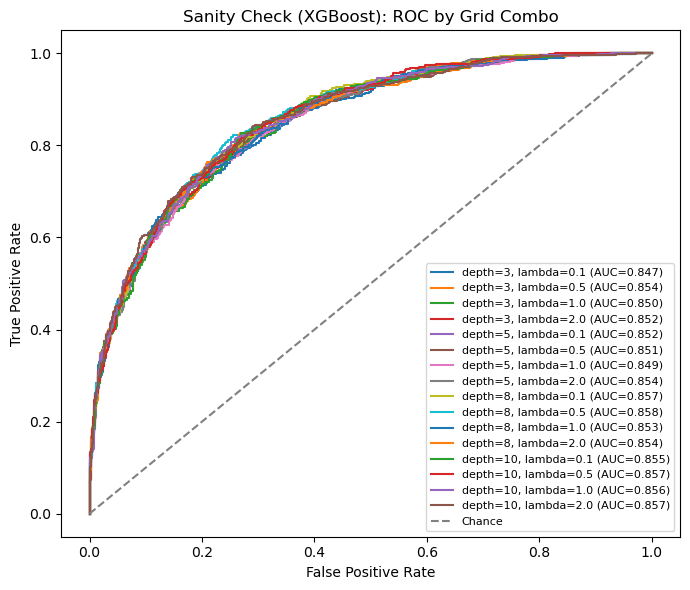

In [ ]:
# Sanity check stage (XGBoost): All definitions, YES + NO codes, scale + embeddings -> Binary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_score, recall_score

code_features = pd.read_csv("features/code_features.csv")
targets_and_folds = pd.read_csv("features/targets_and_folds.csv")

targets_and_folds["target_binary"] = (targets_and_folds["hate_speech_score"] > 0.5).astype(int)
targets_indexed = targets_and_folds.set_index("comment_id")
code_features_indexed = code_features.set_index("comment_id")

PARAM_GRID = {
    "max_depth": [3, 5, 8, 10],
    "reg_lambda": [0.1, 0.5, 1.0, 2.0],
}
GRID_COMBOS = [{"max_depth": d, "reg_lambda": l} for d in PARAM_GRID["max_depth"] for l in PARAM_GRID["reg_lambda"]]

grid_rows = []
fold_rows = []
shap_records = []  # per-fold mean |SHAP| per feature, for importance analysis
combo_probs = {i: {"true": [], "prob": []} for i in range(len(GRID_COMBOS))}  # pooled preds per grid combo, for ROC-by-grid
all_true, all_pred, all_prob = [], [], []

for fold_idx in sorted(targets_and_folds["fold"].unique()):
    fold_idx = int(fold_idx)
    train_ids = targets_and_folds.loc[targets_and_folds["fold"] != fold_idx, "comment_id"]
    test_ids = targets_and_folds.loc[targets_and_folds["fold"] == fold_idx, "comment_id"]

    pca_train = pd.read_csv(f"features/pca/fold_{fold_idx}_train.csv", index_col=0)
    pca_test = pd.read_csv(f"features/pca/fold_{fold_idx}_test.csv", index_col=0)

    X_train = code_features_indexed.loc[train_ids].join(pca_train)
    X_test = code_features_indexed.loc[test_ids].join(pca_test)
    y_train = targets_indexed.loc[train_ids, "target_binary"]
    y_test = targets_indexed.loc[test_ids, "target_binary"]

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / pos

    base_model = XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        n_estimators=200, learning_rate=0.05, min_child_weight=5,
        gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1,
    )

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(base_model, PARAM_GRID, scoring="roc_auc", cv=inner_cv, n_jobs=-1)
    grid.fit(X_train, y_train)

    for params, mean_score, std_score in zip(
        grid.cv_results_["params"], grid.cv_results_["mean_test_score"], grid.cv_results_["std_test_score"]
    ):
        grid_rows.append({
            "fold": fold_idx, "max_depth": params["max_depth"], "reg_lambda": params["reg_lambda"],
            "inner_auc_mean": mean_score, "inner_auc_std": std_score,
        })

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]

    all_true.extend(y_test.tolist())
    all_pred.extend(preds.tolist())
    all_prob.extend(probs.tolist())

    fold_rows.append({
        "fold": fold_idx,
        "best_depth": grid.best_params_["max_depth"],
        "best_lambda": grid.best_params_["reg_lambda"],
        "acc": accuracy_score(y_test, preds),
        "prec": precision_score(y_test, preds),
        "rec": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "auc": roc_auc_score(y_test, probs),
    })

    # SHAP importance for this fold's best model
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
    shap_records.append(mean_abs_shap)

    # fit every grid combo on this fold's train, predict on this fold's test, pool for ROC-by-grid
    for i, params in enumerate(GRID_COMBOS):
        m = XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            n_estimators=200, learning_rate=0.05, min_child_weight=5,
            gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1,
            **params,
        ).fit(X_train, y_train)
        p = m.predict_proba(X_test)[:, 1]
        combo_probs[i]["true"].extend(y_test.tolist())
        combo_probs[i]["prob"].extend(p.tolist())

grid_df = pd.DataFrame(grid_rows)
pivot = grid_df.pivot_table(index=["max_depth", "reg_lambda"], columns="fold", values="inner_auc_mean")
pivot["mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean", ascending=False)
print("Grid combos x folds (inner CV AUC)")
print(pivot.round(3).to_string())

fold_df = pd.DataFrame(fold_rows).set_index("fold")
print("\nPer-fold test performance (best params)")
print(fold_df.round(3).to_string())

print("\nMean +/- std across folds")
summary = fold_df[["acc", "prec", "rec", "f1", "auc"]].agg(["mean", "std"]).round(3)
print(summary.to_string())

print(f"\nPooled: acc={accuracy_score(all_true, all_pred):.3f}  prec={precision_score(all_true, all_pred):.3f}  "
      f"rec={recall_score(all_true, all_pred):.3f}  f1={f1_score(all_true, all_pred):.3f}  "
      f"auc={roc_auc_score(all_true, all_prob):.3f}")

# feature importance: ALL features (codes + PCA), mean |SHAP value| across folds
shap_df = pd.DataFrame(shap_records)
importance = pd.DataFrame({
    "mean_abs_shap": shap_df.mean(axis=0),
    "std_abs_shap": shap_df.std(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 30 features (codes + PCA components) by mean |SHAP value| across folds")
print(importance.head(30).round(4).to_string())

n_pca_in_top30 = importance.head(30).index.str.startswith("pc_").sum()
print(f"\nPCA components in top 30: {n_pca_in_top30} / 30")

# ROC by grid combo (pooled across outer folds), not by fold
plt.figure(figsize=(7, 6))
for i, params in enumerate(GRID_COMBOS):
    fpr, tpr, _ = roc_curve(combo_probs[i]["true"], combo_probs[i]["prob"])
    auc = roc_auc_score(combo_probs[i]["true"], combo_probs[i]["prob"])
    label = f"depth={params['max_depth']}, lambda={params['reg_lambda']} (AUC={auc:.3f})"
    plt.plot(fpr, tpr, label=label)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sanity Check (XGBoost): ROC by Grid Combo")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("viz/sanity_check_xgb_roc.png", dpi=150)
plt.show()

Grid combos x folds (inner CV AUC)
fold       0      1      2      3      4   mean
C                                              
0.005  0.823  0.835  0.852  0.831  0.842  0.837
0.001  0.821  0.836  0.851  0.831  0.840  0.836
0.010  0.818  0.832  0.849  0.825  0.840  0.833
0.100  0.790  0.808  0.818  0.793  0.816  0.805
1.000  0.766  0.781  0.789  0.763  0.784  0.777

Per-fold test performance (best params)
      best_C    acc   prec    rec     f1    auc
fold                                           
0      0.005  0.816  0.595  0.830  0.693  0.890
1      0.001  0.795  0.573  0.713  0.635  0.862
2      0.005  0.795  0.579  0.660  0.617  0.835
3      0.001  0.795  0.580  0.684  0.628  0.864
4      0.005  0.807  0.590  0.766  0.667  0.857

Mean +/- std across folds
        acc   prec    rec     f1    auc
mean  0.801  0.584  0.730  0.648  0.862
std   0.010  0.009  0.068  0.031  0.019

Pooled: acc=0.801  prec=0.584  rec=0.730  f1=0.649  auc=0.855

Top 30 features (codes + PCA components) 

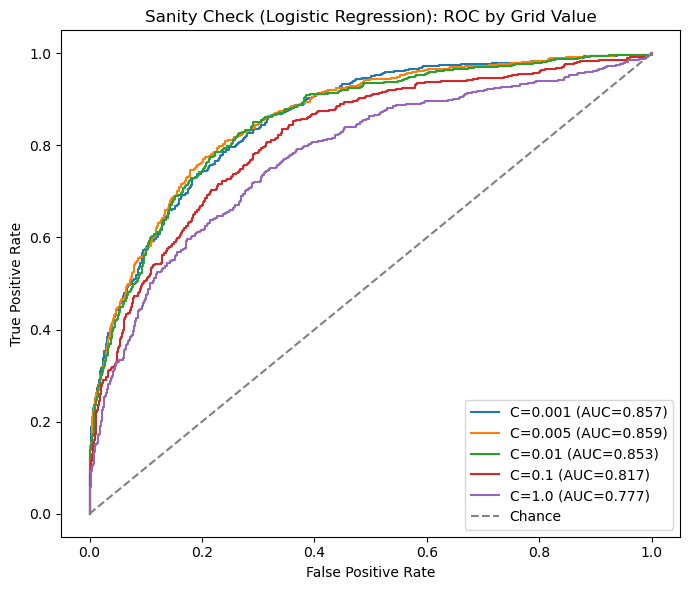

In [ ]:
# Sanity check stage (Logistic Regression): All definitions, YES + NO codes, scale + embeddings -> Binary

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_score, recall_score

warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*")

code_features = pd.read_csv("features/code_features.csv")
targets_and_folds = pd.read_csv("features/targets_and_folds.csv")

targets_and_folds["target_binary"] = (targets_and_folds["hate_speech_score"] > 0.5).astype(int)
targets_indexed = targets_and_folds.set_index("comment_id")
code_features_indexed = code_features.set_index("comment_id")

PARAM_GRID = {"C": [0.001, 0.005, 0.01, 0.1, 1.0]}

grid_rows = []
fold_rows = []
coef_records = []  # per-fold coefficients on ALL features (codes + PCA), for importance analysis
combo_probs = {C: {"true": [], "prob": []} for C in PARAM_GRID["C"]}  # pooled preds per grid value, for ROC-by-grid
all_true, all_pred, all_prob = [], [], []

for fold_idx in sorted(targets_and_folds["fold"].unique()):
    fold_idx = int(fold_idx)
    train_ids = targets_and_folds.loc[targets_and_folds["fold"] != fold_idx, "comment_id"]
    test_ids = targets_and_folds.loc[targets_and_folds["fold"] == fold_idx, "comment_id"]

    pca_train = pd.read_csv(f"features/pca/fold_{fold_idx}_train.csv", index_col=0)
    pca_test = pd.read_csv(f"features/pca/fold_{fold_idx}_test.csv", index_col=0)

    X_train_raw = code_features_indexed.loc[train_ids].join(pca_train)
    X_test_raw = code_features_indexed.loc[test_ids].join(pca_test)
    y_train = targets_indexed.loc[train_ids, "target_binary"]
    y_test = targets_indexed.loc[test_ids, "target_binary"]

    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

    base_model = LogisticRegression(
        penalty="l2", solver="liblinear", class_weight="balanced",
        max_iter=2000, random_state=42,
    )

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(base_model, PARAM_GRID, scoring="roc_auc", cv=inner_cv, n_jobs=-1)
    grid.fit(X_train, y_train)

    for params, mean_score, std_score in zip(
        grid.cv_results_["params"], grid.cv_results_["mean_test_score"], grid.cv_results_["std_test_score"]
    ):
        grid_rows.append({"fold": fold_idx, "C": params["C"], "inner_auc_mean": mean_score, "inner_auc_std": std_score})

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]

    all_true.extend(y_test.tolist())
    all_pred.extend(preds.tolist())
    all_prob.extend(probs.tolist())

    fold_rows.append({
        "fold": fold_idx, "best_C": grid.best_params_["C"],
        "acc": accuracy_score(y_test, preds), "prec": precision_score(y_test, preds),
        "rec": recall_score(y_test, preds), "f1": f1_score(y_test, preds),
        "auc": roc_auc_score(y_test, probs),
    })

    coefs = pd.Series(best_model.coef_[0], index=X_train.columns)
    coef_records.append(coefs)

    # fit every grid value on this fold's train, predict on this fold's test, pool for ROC-by-grid
    for C in PARAM_GRID["C"]:
        m = LogisticRegression(penalty="l2", solver="liblinear", class_weight="balanced",
                                max_iter=2000, random_state=42, C=C).fit(X_train, y_train)
        p = m.predict_proba(X_test)[:, 1]
        combo_probs[C]["true"].extend(y_test.tolist())
        combo_probs[C]["prob"].extend(p.tolist())

grid_df = pd.DataFrame(grid_rows)
pivot = grid_df.pivot_table(index="C", columns="fold", values="inner_auc_mean")
pivot["mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean", ascending=False)
print("Grid combos x folds (inner CV AUC)")
print(pivot.round(3).to_string())

fold_df = pd.DataFrame(fold_rows).set_index("fold")
print("\nPer-fold test performance (best params)")
print(fold_df.round(3).to_string())

print("\nMean +/- std across folds")
summary = fold_df[["acc", "prec", "rec", "f1", "auc"]].agg(["mean", "std"]).round(3)
print(summary.to_string())

print(f"\nPooled: acc={accuracy_score(all_true, all_pred):.3f}  prec={precision_score(all_true, all_pred):.3f}  "
      f"rec={recall_score(all_true, all_pred):.3f}  f1={f1_score(all_true, all_pred):.3f}  "
      f"auc={roc_auc_score(all_true, all_prob):.3f}")

# feature importance: ALL features (codes + PCA), mean coefficient across folds
coef_df = pd.DataFrame(coef_records)
importance = pd.DataFrame({
    "mean_coef": coef_df.mean(axis=0),
    "std_coef": coef_df.std(axis=0),
    "mean_abs_coef": coef_df.abs().mean(axis=0),
    "sign_consistent": coef_df.apply(lambda col: (np.sign(col) == np.sign(col.iloc[0])).all() if col.iloc[0] != 0 else False),
})
importance = importance.sort_values("mean_abs_coef", ascending=False)

print("\nTop 30 features (codes + PCA components) by mean |coefficient| across folds")
print(importance.head(30).round(3).to_string())

n_pca_in_top30 = importance.head(30).index.str.startswith("pc_").sum()
print(f"\nPCA components in top 30: {n_pca_in_top30} / 30")

# ROC by grid value (pooled across outer folds), not by fold
plt.figure(figsize=(7, 6))
for C in PARAM_GRID["C"]:
    fpr, tpr, _ = roc_curve(combo_probs[C]["true"], combo_probs[C]["prob"])
    auc = roc_auc_score(combo_probs[C]["true"], combo_probs[C]["prob"])
    plt.plot(fpr, tpr, label=f"C={C} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sanity Check (Logistic Regression): ROC by Grid Value")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("viz/sanity_check_logreg_roc.png", dpi=150)
plt.show()

### Evaluation

These models ...

# Embedding Only

the

In [24]:
# shared feature builders for PCA vs raw embeddings, reused across all three targets

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print(f"Working directory: {os.getcwd()}")

targets_and_folds = pd.read_csv("features/targets_and_folds.csv")
targets_indexed = targets_and_folds.set_index("comment_id")
embed_df = pd.read_csv("features/embeddings.csv").set_index("comment_id")

FOLDS = sorted(targets_and_folds["fold"].unique())

RAW_SCALED_DIR = os.path.abspath("features/raw_scaled")
os.makedirs(RAW_SCALED_DIR, exist_ok=True)
print(f"Raw scaled features will be saved to: {RAW_SCALED_DIR}")

def get_ids(fold_idx):
    train_ids = targets_and_folds.loc[targets_and_folds["fold"] != fold_idx, "comment_id"]
    test_ids = targets_and_folds.loc[targets_and_folds["fold"] == fold_idx, "comment_id"]
    return train_ids, test_ids

def get_pca_features(fold_idx, train_ids, test_ids):
    pca_train = pd.read_csv(f"features/pca/fold_{int(fold_idx)}_train.csv", index_col=0)
    pca_test = pd.read_csv(f"features/pca/fold_{int(fold_idx)}_test.csv", index_col=0)
    return pca_train.loc[train_ids], pca_test.loc[test_ids]

def get_raw_features(fold_idx, train_ids, test_ids, force=False):
    raw_train_path = os.path.join(RAW_SCALED_DIR, f"fold_{int(fold_idx)}_train.csv")
    raw_test_path = os.path.join(RAW_SCALED_DIR, f"fold_{int(fold_idx)}_test.csv")

    if not force and os.path.exists(raw_train_path) and os.path.exists(raw_test_path):
        X_train = pd.read_csv(raw_train_path, index_col=0)
        X_test = pd.read_csv(raw_test_path, index_col=0)
        return X_train.loc[train_ids], X_test.loc[test_ids]

    X_train_raw = embed_df.loc[train_ids]
    X_test_raw = embed_df.loc[test_ids]
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), index=X_train_raw.index, columns=X_train_raw.columns)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), index=X_test_raw.index, columns=X_test_raw.columns)

    X_train.to_csv(raw_train_path)
    X_test.to_csv(raw_test_path)

    assert os.path.exists(raw_train_path), f"FAILED to write {raw_train_path}"
    assert os.path.exists(raw_test_path), f"FAILED to write {raw_test_path}"

    return X_train, X_test

REPRESENTATIONS = {"pca": get_pca_features, "raw": get_raw_features}

LOGREG_C = 0.005
XGB_PARAMS = dict(max_depth=5, reg_lambda=1.0)

# save of raw scaled features, with explicit confirmation per fold
for fold_idx in FOLDS:
    train_ids, test_ids = get_ids(fold_idx)
    get_raw_features(fold_idx, train_ids, test_ids, force=True)
    print(f"fold {int(fold_idx)}: saved train/test raw scaled features")

saved_files = os.listdir(RAW_SCALED_DIR)
print(f"\nFiles now in {RAW_SCALED_DIR}:")
print(saved_files)
assert len(saved_files) == len(FOLDS) * 2, f"Expected {len(FOLDS)*2} files, found {len(saved_files)}"

Working directory: c:\Users\jwram\.ipython\antisemitism_classifier\pilot
Raw scaled features will be saved to: c:\Users\jwram\.ipython\antisemitism_classifier\pilot\features\raw_scaled
fold 0: saved train/test raw scaled features
fold 1: saved train/test raw scaled features
fold 2: saved train/test raw scaled features
fold 3: saved train/test raw scaled features
fold 4: saved train/test raw scaled features

Files now in c:\Users\jwram\.ipython\antisemitism_classifier\pilot\features\raw_scaled:
['fold_0_test.csv', 'fold_0_train.csv', 'fold_1_test.csv', 'fold_1_train.csv', 'fold_2_test.csv', 'fold_2_train.csv', 'fold_3_test.csv', 'fold_3_train.csv', 'fold_4_test.csv', 'fold_4_train.csv']


In [25]:
# Embeddings baseline
# Binary target: PCA vs raw embeddings, Logistic Regression vs XGBoost

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

targets_and_folds["target_binary"] = (targets_and_folds["hate_speech_score"] > 0.5).astype(int)
targets_indexed = targets_and_folds.set_index("comment_id")

rows = []

for rep_name, get_features in REPRESENTATIONS.items():
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = targets_indexed.loc[train_ids, "target_binary"]
        y_test = targets_indexed.loc[test_ids, "target_binary"]

        logreg = LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                     class_weight="balanced", max_iter=2000, random_state=42)
        logreg.fit(X_train, y_train)
        lr_probs = logreg.predict_proba(X_test)[:, 1]
        lr_preds = logreg.predict(X_test)

        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        xgb = XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                             n_estimators=200, learning_rate=0.05, min_child_weight=5,
                             gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=neg/pos, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb.fit(X_train, y_train)
        xgb_probs = xgb.predict_proba(X_test)[:, 1]
        xgb_preds = xgb.predict(X_test)

        for model_name, preds, probs in [("logreg", lr_preds, lr_probs), ("xgboost", xgb_preds, xgb_probs)]:
            rows.append({
                "representation": rep_name, "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds), "prec": precision_score(y_test, preds),
                "rec": recall_score(y_test, preds), "f1": f1_score(y_test, preds),
                "auc": roc_auc_score(y_test, probs),
            })

binary_results = pd.DataFrame(rows)
summary = binary_results.groupby(["representation", "model"])[["acc", "prec", "rec", "f1", "auc"]].agg(["mean", "std"])
print("Binary target: PCA vs raw embeddings, mean +/- std across folds")
print(summary.round(3).to_string())

Binary target: PCA vs raw embeddings, mean +/- std across folds
                          acc          prec           rec            f1           auc       
                         mean    std   mean    std   mean    std   mean    std   mean    std
representation model                                                                        
pca            logreg   0.716  0.028  0.463  0.028  0.801  0.034  0.587  0.030  0.817  0.025
               xgboost  0.769  0.008  0.551  0.020  0.454  0.021  0.498  0.010  0.793  0.019
raw            logreg   0.722  0.022  0.470  0.022  0.803  0.038  0.592  0.024  0.821  0.025
               xgboost  0.782  0.013  0.586  0.030  0.448  0.045  0.507  0.038  0.804  0.022


In [35]:
# Embeddings baseline
# Ordinal target: PCA vs raw embeddings, Ordinal Logistic vs Multinomial vs OvR vs OvO vs XGBoost (regression-threshold)

import mord
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

ordinal_map = {"supportive": 0, "neutral": 1, "hate": 2}
targets_and_folds["target_ordinal"] = targets_and_folds["ordinal_label"].map(ordinal_map)
targets_indexed = targets_and_folds.set_index("comment_id")

rows = []

for rep_name, get_features in REPRESENTATIONS.items():
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]
        y_test = targets_indexed.loc[test_ids, "target_ordinal"]

        # ordinal-aware: proportional odds
        ord_logit = mord.LogisticIT(alpha=1.0 / LOGREG_C)
        ord_logit.fit(X_train.values, y_train.values)
        ord_preds = ord_logit.predict(X_test.values)

        # unordered: native multinomial (softmax) -- lbfgs's only multiclass behavior, no wrapper needed
        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced",
                                          max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)
        multi_preds = multi_logit.predict(X_test)

        # unordered: one-vs-rest, explicit wrapper for clarity (liblinear's implicit OvR is no longer settable via keyword)
        ovr_logit = OneVsRestClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovr_logit.fit(X_train, y_train)
        ovr_preds = ovr_logit.predict(X_test)

        # unordered: one-vs-one, same base estimator as OvR for a fair comparison of wrapper strategy alone
        ovo_logit = OneVsOneClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovo_logit.fit(X_train, y_train)
        ovo_preds = ovo_logit.predict(X_test)

        # ordinal-aware: XGBoost regression-then-threshold
        xgb_reg = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                                min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                                colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb_reg.fit(X_train, y_train)
        xgb_raw_preds = xgb_reg.predict(X_test)
        xgb_preds = np.digitize(xgb_raw_preds, bins=[0.5, 1.5])

        for model_name, preds in [
            ("ordinal_logit", ord_preds),
            ("multinomial_logit", multi_preds),
            ("ovr_logit", ovr_preds),
            ("ovo_logit", ovo_preds),
            ("xgboost_thresh", xgb_preds),
        ]:
            rows.append({
                "representation": rep_name, "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds),
                "f1_macro": f1_score(y_test, preds, average="macro"),
                "qwk": cohen_kappa_score(y_test, preds, weights="quadratic"),
            })

ordinal_results = pd.DataFrame(rows)
summary = ordinal_results.groupby(["representation", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"])
print("Ordinal target: PCA vs raw embeddings, mean +/- std across folds")
print(summary.round(3).to_string())

Ordinal target: PCA vs raw embeddings, mean +/- std across folds
                                    acc        f1_macro           qwk       
                                   mean    std     mean    std   mean    std
representation model                                                        
pca            multinomial_logit  0.573  0.019    0.561  0.018  0.512  0.038
               ordinal_logit      0.578  0.020    0.556  0.020  0.542  0.041
               ovo_logit          0.575  0.020    0.560  0.019  0.513  0.034
               ovr_logit          0.580  0.028    0.565  0.027  0.522  0.045
               xgboost_thresh     0.482  0.012    0.422  0.023  0.384  0.029
raw            multinomial_logit  0.579  0.016    0.567  0.014  0.512  0.040
               ordinal_logit      0.581  0.027    0.560  0.029  0.550  0.046
               ovo_logit          0.570  0.017    0.556  0.016  0.503  0.029
               ovr_logit          0.580  0.013    0.566  0.014  0.515  0.031
           

In [31]:
# Embeddings baseline
# Continuous target: PCA vs raw embeddings, Ridge (tuned) vs XGBoost Regressor

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr

ALPHA_GRID = {"alpha": [0.1, 1.0, 10.0, 100.0, 1000.0, 3000.0, 5000.0]}

grid_rows = []
fold_rows = []

for rep_name, get_features in REPRESENTATIONS.items():
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = targets_indexed.loc[train_ids, "hate_speech_score"]
        y_test = targets_indexed.loc[test_ids, "hate_speech_score"]

        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        grid = GridSearchCV(Ridge(random_state=42), ALPHA_GRID, scoring="r2", cv=inner_cv, n_jobs=1)
        grid.fit(X_train, y_train)

        for params, mean_score in zip(grid.cv_results_["params"], grid.cv_results_["mean_test_score"]):
            grid_rows.append({"representation": rep_name, "fold": fold_idx, "alpha": params["alpha"], "inner_r2": mean_score})

        ridge = grid.best_estimator_
        ridge_preds = ridge.predict(X_test)

        xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                            min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                            colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb.fit(X_train, y_train)
        xgb_preds = xgb.predict(X_test)

        for model_name, preds, best_alpha in [
            ("ridge", ridge_preds, grid.best_params_["alpha"]),
            ("xgboost", xgb_preds, None),
        ]:
            r, _ = pearsonr(y_test, preds)
            fold_rows.append({
                "representation": rep_name, "model": model_name, "fold": fold_idx, "best_alpha": best_alpha,
                "r2": r2_score(y_test, preds), "mae": mean_absolute_error(y_test, preds),
                "pearson_r": r,
            })

# grid search report: alpha x fold x representation
grid_df = pd.DataFrame(grid_rows)
for rep_name in REPRESENTATIONS:
    pivot = grid_df[grid_df["representation"] == rep_name].pivot_table(index="alpha", columns="fold", values="inner_r2")
    pivot["mean"] = pivot.mean(axis=1)
    print(f"{rep_name} -- Ridge alpha grid (inner CV R2)")
    print(pivot.sort_values("mean", ascending=False).round(3).to_string())
    print()

# final test performance
continuous_results = pd.DataFrame(fold_rows)
summary = continuous_results.groupby(["representation", "model"])[["r2", "mae", "pearson_r"]].agg(["mean", "std"])
print("Continuous target: PCA vs raw embeddings, mean +/- std across folds")
print(summary.round(3).to_string())

pca -- Ridge alpha grid (inner CV R2)
fold      0.0    1.0    2.0    3.0    4.0   mean
alpha                                           
1000.0  0.444  0.441  0.447  0.442  0.459  0.446
3000.0  0.419  0.416  0.429  0.424  0.433  0.424
100.0   0.404  0.402  0.397  0.394  0.418  0.403
5000.0  0.386  0.384  0.398  0.394  0.399  0.392
10.0    0.384  0.383  0.374  0.374  0.397  0.382
1.0     0.382  0.380  0.371  0.371  0.394  0.380
0.1     0.381  0.380  0.371  0.371  0.394  0.379

raw -- Ridge alpha grid (inner CV R2)
fold      0.0    1.0    2.0    3.0    4.0   mean
alpha                                           
1000.0  0.455  0.445  0.453  0.447  0.468  0.453
3000.0  0.423  0.418  0.431  0.426  0.436  0.427
5000.0  0.388  0.385  0.399  0.395  0.401  0.393
100.0   0.409  0.378  0.385  0.378  0.412  0.392
10.0    0.307  0.260  0.278  0.262  0.298  0.281
1.0     0.260  0.208  0.230  0.206  0.244  0.230
0.1     0.253  0.199  0.222  0.194  0.235  0.220

Continuous target: PCA vs raw embeddings

# Internal Construct

In [37]:
# Internal construct validity stage
# Predicting the model's own code labels (E/I/A) from embeddings only, per definition + code subset

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"IHRA": "I", "Nexus": "N", "JDA": "J"}

MIN_SUPPORT = 10  # minimum non-N labels required for a code to be included as a target

def get_code_columns(definition, code_subset, code_features_columns):
    """Return the list of one-hot column names (e.g. 'D1HATE_E') to use as targets
    for a given definition ('IHRA'/'Nexus'/'JDA'/'All') and code_subset ('yes_only'/'yes_and_no')."""
    if definition == "All":
        relevant_codes = code_block_map.index
    else:
        prefix = definition_prefix_map[definition]
        relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index

    if code_subset == "yes_only":
        relevant_codes = [c for c in relevant_codes if not code_block_map[c].__contains__("NO")]
    # "yes_and_no" keeps all relevant_codes as-is

    cols = [c for code in relevant_codes for c in [f"{code}_E", f"{code}_I", f"{code}_A"] if c in code_features_columns]
    return cols

def run_internal_construct_stage(definition, code_subset, representation="raw"):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    target_cols = get_code_columns(definition, code_subset, code_features.columns)

    # filter to codes with sufficient support
    support = code_features[target_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    dropped_n = len(target_cols) - len(kept_cols)

    print(f"{definition} / {code_subset}: {len(kept_cols)} target columns kept, {dropped_n} dropped for low support (<{MIN_SUPPORT})")

    get_features = get_pca_features if representation == "pca" else get_raw_features
    rows = []

    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = code_features.loc[train_ids, kept_cols]
        y_test = code_features.loc[test_ids, kept_cols]

        logreg = MultiOutputClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                               class_weight="balanced", max_iter=2000, random_state=42)
        )
        logreg.fit(X_train, y_train)
        logreg_probs = np.array([est.predict_proba(X_test)[:, 1] for est in logreg.estimators_]).T
        logreg_preds = logreg.predict(X_test)

        xgb = MultiOutputClassifier(
            XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                          n_estimators=200, learning_rate=0.05, min_child_weight=5,
                          gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, **XGB_PARAMS)
        )
        xgb.fit(X_train, y_train)
        xgb_probs = np.array([est.predict_proba(X_test)[:, 1] for est in xgb.estimators_]).T
        xgb_preds = xgb.predict(X_test)

        for model_name, preds, probs in [("logreg", logreg_preds, logreg_probs), ("xgboost", xgb_preds, xgb_probs)]:
            aucs, f1s = [], []
            for i, col in enumerate(kept_cols):
                if y_test.iloc[:, i].nunique() < 2:
                    continue  # skip columns with no positive/negative variation in this fold's test set
                aucs.append(roc_auc_score(y_test.iloc[:, i], probs[:, i]))
                f1s.append(f1_score(y_test.iloc[:, i], preds[:, i]))
            rows.append({
                "definition": definition, "code_subset": code_subset, "representation": representation,
                "model": model_name, "fold": fold_idx,
                "macro_auc": np.mean(aucs), "macro_f1": np.mean(f1s), "n_codes_evaluated": len(aucs),
            })

    return pd.DataFrame(rows)

In [38]:
all_stage_results = []
for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        all_stage_results.append(run_internal_construct_stage(definition, code_subset))

internal_construct_results = pd.concat(all_stage_results, ignore_index=True)
summary = internal_construct_results.groupby(["definition", "code_subset", "model"])[["macro_auc", "macro_f1"]].agg(["mean", "std"])
print(summary.round(3).to_string())

IHRA / yes_only: 93 target columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no: 96 target columns kept, 54 dropped for low support (<10)
Nexus / yes_only: 48 target columns kept, 18 dropped for low support (<10)
Nexus / yes_and_no: 59 target columns kept, 31 dropped for low support (<10)
JDA / yes_only: 51 target columns kept, 42 dropped for low support (<10)
JDA / yes_and_no: 72 target columns kept, 69 dropped for low support (<10)
All / yes_only: 192 target columns kept, 114 dropped for low support (<10)
All / yes_and_no: 227 target columns kept, 154 dropped for low support (<10)
                               macro_auc        macro_f1       
                                    mean    std     mean    std
definition code_subset model                                   
All        yes_and_no  logreg      0.819  0.017    0.155  0.007
                       xgboost     0.753  0.019    0.039  0.008
           yes_only    logreg      0.804  0.020    0.160  0.008
              

In [ ]:
# In-depth breakdown

import pandas as pd
import numpy as np
from scipy import stats

print(f"Available columns: {internal_construct_results.columns.tolist()}")
print(f"Total rows: {len(internal_construct_results)}")
print(f"Folds per (definition, code_subset, model): {internal_construct_results.groupby(['definition','code_subset','model']).size().unique()}")

# Full per-fold detail
print("\n=== Per-fold detail, all combinations ===")
pivot_auc = internal_construct_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="macro_auc"
)
print(pivot_auc.round(3).to_string())

# n_codes_evaluated per row: check for imbalance/instability across folds
print("\n=== n_codes_evaluated per fold (should be stable within a definition/code_subset) ===")
pivot_n = internal_construct_results.pivot_table(
    index=["definition", "code_subset"], columns="fold", values="n_codes_evaluated"
)
print(pivot_n.to_string())

# Paired comparison: logreg vs xgboost, per definition/code_subset, using the 5 matched folds
print("\n=== Paired logreg vs xgboost (Wilcoxon signed-rank across folds) ===")
rows = []
for (defn, subset), grp in internal_construct_results.groupby(["definition", "code_subset"]):
    lr = grp[grp["model"] == "logreg"].sort_values("fold")["macro_auc"].values
    xg = grp[grp["model"] == "xgboost"].sort_values("fold")["macro_auc"].values
    if len(lr) == len(xg) and len(lr) > 1:
        stat, p = stats.wilcoxon(lr, xg)
        rows.append({
            "definition": defn, "code_subset": subset,
            "logreg_mean_auc": lr.mean(), "xgboost_mean_auc": xg.mean(),
            "diff": lr.mean() - xg.mean(), "wilcoxon_p": p,
        })
paired_df = pd.DataFrame(rows)
print(paired_df.round(4).to_string(index=False))

# yes_only vs yes_and_no, within model, within definition
print("\n=== yes_only vs yes_and_no (paired across folds, within model) ===")
rows = []
for (defn, model), grp in internal_construct_results.groupby(["definition", "model"]):
    yo = grp[grp["code_subset"] == "yes_only"].sort_values("fold")["macro_auc"].values
    yn = grp[grp["code_subset"] == "yes_and_no"].sort_values("fold")["macro_auc"].values
    if len(yo) == len(yn) and len(yo) > 1:
        stat, p = stats.wilcoxon(yo, yn)
        rows.append({
            "definition": defn, "model": model,
            "yes_only_mean_auc": yo.mean(), "yes_and_no_mean_auc": yn.mean(),
            "diff": yn.mean() - yo.mean(), "wilcoxon_p": p,
        })
subset_df = pd.DataFrame(rows)
print(subset_df.round(4).to_string(index=False))

# Definition ranking with bootstrapped 95% CI on macro_auc (logreg only)
print("\n=== Definition ranking, logreg, macro_auc with 95% CI (bootstrap over folds) ===")
rows = []
rng = np.random.default_rng(42)
for (defn, subset), grp in internal_construct_results[internal_construct_results["model"] == "logreg"].groupby(["definition", "code_subset"]):
    vals = grp["macro_auc"].values
    boot_means = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(2000)]
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    rows.append({
        "definition": defn, "code_subset": subset,
        "mean_auc": vals.mean(), "ci_lo": ci_lo, "ci_hi": ci_hi,
    })
ci_df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
print(ci_df.round(3).to_string(index=False))

# AUC vs F1 gap
print("\n=== AUC vs F1 gap (large gap suggests default 0.5 threshold is miscalibrated) ===")
gap_df = internal_construct_results.groupby(["definition", "code_subset", "model"])[["macro_auc", "macro_f1"]].mean()
gap_df["auc_f1_gap"] = gap_df["macro_auc"] - gap_df["macro_f1"]
print(gap_df.sort_values("auc_f1_gap", ascending=False).round(3).to_string())

# Correlation between n_codes_evaluated and performance
print("\n=== Correlation: n_codes_evaluated vs macro_auc (across all rows) ===")
r, p = stats.pearsonr(internal_construct_results["n_codes_evaluated"], internal_construct_results["macro_auc"])
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

Available columns: ['definition', 'code_subset', 'representation', 'model', 'fold', 'macro_auc', 'macro_f1', 'n_codes_evaluated']
Total rows: 80
Folds per (definition, code_subset, model): [5]

=== Per-fold detail, all combinations ===
fold                              0.0    1.0    2.0    3.0    4.0
definition code_subset model                                     
All        yes_and_no  logreg   0.805  0.832  0.828  0.833  0.797
                       xgboost  0.737  0.762  0.772  0.768  0.729
           yes_only    logreg   0.788  0.821  0.818  0.817  0.777
                       xgboost  0.738  0.762  0.776  0.768  0.728
IHRA       yes_and_no  logreg   0.797  0.796  0.820  0.823  0.776
                       xgboost  0.719  0.754  0.770  0.756  0.726
           yes_only    logreg   0.795  0.797  0.823  0.820  0.771
                       xgboost  0.723  0.760  0.775  0.760  0.723
JDA        yes_and_no  logreg   0.823  0.863  0.830  0.850  0.818
                       xgboost  0.745 

In [42]:
import pandas as pd
import numpy as np
from scipy import stats

# Correlation within each (definition, model) group separately
print("=== n_codes_evaluated vs macro_auc, within each definition x model group ===")
rows = []
for (defn, model), grp in internal_construct_results.groupby(["definition", "model"]):
    if grp["n_codes_evaluated"].nunique() > 1:  # need variation to compute a correlation
        r, p = stats.pearsonr(grp["n_codes_evaluated"], grp["macro_auc"])
        rows.append({"definition": defn, "model": model, "n_rows": len(grp), "r": r, "p": p})
    else:
        rows.append({"definition": defn, "model": model, "n_rows": len(grp), "r": np.nan, "p": np.nan})
within_df = pd.DataFrame(rows)
print(within_df.round(3).to_string(index=False))

# Between-group comparison
print("\n=== Between-group: mean n_codes_evaluated vs mean macro_auc, per definition x code_subset ===")
group_means = internal_construct_results.groupby(["definition", "code_subset"]).agg(
    mean_n_codes=("n_codes_evaluated", "mean"),
    mean_auc=("macro_auc", "mean"),
).reset_index()
print(group_means.round(3).to_string(index=False))
r_between, p_between = stats.pearsonr(group_means["mean_n_codes"], group_means["mean_auc"])
print(f"\nBetween-group Pearson r = {r_between:.3f}, p = {p_between:.4f}")

# Partial correlation
import statsmodels.api as sm

df = internal_construct_results.copy()

X = pd.get_dummies(df[["definition", "model"]], drop_first=True).astype(float)
X = sm.add_constant(X)

def residualize(y, X):
    return sm.OLS(y.astype(float), X).fit().resid

resid_n = residualize(df["n_codes_evaluated"], X)
resid_auc = residualize(df["macro_auc"], X)

r_partial, p_partial = stats.pearsonr(resid_n, resid_auc)
print(f"=== Partial correlation (controlling for definition + model) ===")
print(f"r = {r_partial:.3f}, p = {p_partial:.4f}")

=== n_codes_evaluated vs macro_auc, within each definition x model group ===
definition   model  n_rows      r     p
       All  logreg      10  0.413 0.236
       All xgboost      10  0.016 0.966
      IHRA  logreg      10  0.450 0.192
      IHRA xgboost      10  0.056 0.878
       JDA  logreg      10  0.449 0.194
       JDA xgboost      10 -0.433 0.212
     Nexus  logreg      10  0.491 0.149
     Nexus xgboost      10  0.290 0.417

=== Between-group: mean n_codes_evaluated vs mean macro_auc, per definition x code_subset ===
definition code_subset  mean_n_codes  mean_auc
       All  yes_and_no         222.2     0.786
       All    yes_only         187.8     0.779
      IHRA  yes_and_no          93.8     0.774
      IHRA    yes_only          90.8     0.775
       JDA  yes_and_no          70.8     0.799
       JDA    yes_only          50.2     0.796
     Nexus  yes_and_no          57.6     0.790
     Nexus    yes_only          46.8     0.770

Between-group Pearson r = -0.115, p = 0.7864

In [43]:
import pandas as pd

code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")

# correlation matrix restricted to YES vs NO code pairs within the same definition
corr = code_features.corr()

# flag pairs with |correlation| above a threshold as a quick multicollinearity check
high_corr_pairs = (
    corr.where(lambda x: (x.abs() > 0.5) & (x.abs() < 1.0))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "code_a", "level_1": "code_b", 0: "correlation"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["code_a"] < high_corr_pairs["code_b"]]  # drop mirror duplicates
print(f"{len(high_corr_pairs)} feature pairs with |r| > 0.5")
print(high_corr_pairs.sort_values("correlation", key=abs, ascending=False).head(20).to_string(index=False))

486 feature pairs with |r| > 0.5
                 code_a                  code_b  correlation
            E13PEOPLE_A             E13TARGET_A     0.980412
            N1BELIEFS_E    N1NEGATIVEATTITUDE_E     0.976066
         N2CONSPIRACY_E    N4HIDDENCONSPIRACY_E     0.971564
            E13PEOPLE_I             E13TARGET_I     0.968153
            E13PEOPLE_E             E13TARGET_E     0.957238
            N1BELIEFS_A    N1NEGATIVEATTITUDE_A     0.936262
     A3DISCRIMINATION_A            A3SWASTIKA_A     0.925572
            A2DISEASE_A            A3SWASTIKA_A     0.925572
 N10SELFDETERMINATION_A  N11SELFDETERMINATION_A     0.925572
 N10SELFDETERMINATION_A N11JEWISHRIGHTSDEFINE_A     0.925572
 N10SELFDETERMINATION_A       N11JEWISHRIGHTS_A     0.912627
       E2CONTROLMEDIA_A        E2CONTROLOTHER_A     0.912134
            N1BELIEFS_I    N1NEGATIVEATTITUDE_I     0.904941
     E2CONTROLECONOMY_A        E2CONTROLMEDIA_A     0.902897
 N10SELFDETERMINATION_I N11JEWISHRIGHTSDEFINE_I     

In [44]:
# Isolate YES-vs-NO code correlations using actual block assignment

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]

no_codes = code_block_map[code_block_map.str.contains("NO")].index.tolist()
yes_codes = code_block_map[~code_block_map.str.contains("NO")].index.tolist()

print(f"{len(no_codes)} codes from NO blocks, {len(yes_codes)} codes from YES blocks")

# restrict the correlation matrix to YES-code columns x NO-code columns only
no_cols = [c for c in code_features.columns for code in no_codes if c.startswith(f"{code}_")]
yes_cols = [c for c in code_features.columns for code in yes_codes if c.startswith(f"{code}_")]

corr_matrix = code_features[yes_cols + no_cols].corr()
yes_no_corr = corr_matrix.loc[yes_cols, no_cols]

pairs = (
    yes_no_corr.stack()
    .reset_index()
    .rename(columns={"level_0": "yes_code", "level_1": "no_code", 0: "correlation"})
)
pairs = pairs[pairs["correlation"].abs() > 0.3].sort_values("correlation", key=abs, ascending=False)

print(f"\n{len(pairs)} YES-NO column pairs with |r| > 0.3")
print(pairs.head(30).to_string(index=False))

25 codes from NO blocks, 102 codes from YES blocks

31 YES-NO column pairs with |r| > 0.3
              yes_code                 no_code  correlation
B6CHARACTERIZEISRAEL_E      C13ISRAELCOMPARE_E     0.499599
      E7ISRAELRACIST_I        N16NATIONALISM_I     0.436212
      E7ISRAELRACIST_A      C13ISRAELCOMPARE_A     0.407485
   N12DOUBLESTANDARD_I   N17DISPROPORTIONATE_I     0.407485
        A4ISRAELEVIL_A     N15HARSHCRITICISM_E     0.399031
        A4ISRAELEVIL_I     N15HARSHCRITICISM_I     0.395219
    E8DOUBLESTANDARD_I      D2DOUBLESTANDARD_I     0.384314
      E7ISRAELRACIST_I C13ISRAELINSTITUTIONS_I     0.374516
N10SELFDETERMINATION_I        N16NATIONALISM_I     0.368271
        A4ISRAELEVIL_A    N13ISRAELCRITICISM_E     0.367649
      D2ISRAELTARGET_E     N15HARSHCRITICISM_I     0.364892
        A4ISRAELEVIL_I    N13ISRAELCRITICISM_I     0.358405
      E8UNIQUEDEMAND_A        C12EQUALRIGHTS_E     0.352892
        A4ISRAELEVIL_A     C13ISRAELPOLICIES_E     0.351663
      D2IS

In [46]:
# Check whether within-block code pairs are more correlated than across-block pairs

import itertools
import pandas as pd
from scipy import stats

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]

code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")

all_code_cols = code_features.columns.tolist()
col_to_code = {c: c.rsplit("_", 1)[0] for c in all_code_cols}
col_to_block = {c: code_block_map.get(col_to_code[c], None) for c in all_code_cols}

corr_full = code_features[all_code_cols].corr()

rows = []
for col_a, col_b in itertools.combinations(all_code_cols, 2):
    code_a, code_b = col_to_code[col_a], col_to_code[col_b]
    if code_a == code_b:
        continue
    block_a, block_b = col_to_block[col_a], col_to_block[col_b]
    if block_a is None or block_b is None:
        continue
    r = corr_full.loc[col_a, col_b]
    rows.append({
        "col_a": col_a, "col_b": col_b,
        "block_a": block_a, "block_b": block_b,
        "same_block": block_a == block_b,
        "correlation": r,
    })

pair_df = pd.DataFrame(rows)

print(f"Total pairs checked: {len(pair_df)}")
print(f"Same-block pairs: {pair_df['same_block'].sum()}")
print(f"Different-block pairs: {(~pair_df['same_block']).sum()}")

# diagnose NaN correlations before testing
nan_pairs = pair_df[pair_df["correlation"].isna()]
print(f"\n{len(nan_pairs)} pairs with NaN correlation")

nan_cols = set(nan_pairs["col_a"]).union(set(nan_pairs["col_b"]))
print(f"{len(nan_cols)} unique columns implicated in NaN correlations")

zero_var_cols = [c for c in nan_cols if code_features[c].nunique() <= 1]
print(f"{len(zero_var_cols)} of those are zero-variance (constant) columns")
print(sorted(zero_var_cols)[:20])

# drop NaNs, then compare same-block vs different-block
pair_df_clean = pair_df.dropna(subset=["correlation"])

print("\n=== Mean |correlation| by same-block vs different-block (NaNs dropped) ===")
summary = pair_df_clean.assign(abs_corr=pair_df_clean["correlation"].abs()).groupby("same_block")["abs_corr"].agg(["mean", "std", "count"])
print(summary.round(4).to_string())

same = pair_df_clean.loc[pair_df_clean["same_block"], "correlation"].abs()
diff = pair_df_clean.loc[~pair_df_clean["same_block"], "correlation"].abs()

u_stat, p_val = stats.mannwhitneyu(same, diff, alternative="greater")
print(f"\nMann-Whitney U (same-block > different-block, |correlation|): p = {p_val:.6e}")
print(f"same-block n={len(same)}, different-block n={len(diff)}")

Total pairs checked: 72009
Same-block pairs: 6579
Different-block pairs: 65430

8089 pairs with NaN correlation
381 unique columns implicated in NaN correlations
22 of those are zero-variance (constant) columns
['A3SWASTIKA_E', 'A3SWASTIKA_I', 'A4ROTHSCHILD_A', 'A5HOLOCAUSTMECHANISM_A', 'A5HOLOCAUSTMECHANISM_E', 'B8FORCECONDEMN_A', 'B8FORCECONDEMN_E', 'C12EQUALRIGHTS_I', 'C12SOLUTIONS_I', 'C14BDS_A', 'E12CRIMINALMATERIAL_E', 'E13CEMETERIES_A', 'E13CEMETERIES_E', 'E13SCHOOLS_E', 'E4HOLOCAUSTINTENT_E', 'E4HOLOCAUSTMECHANISM_E', 'E5HOLOCAUSTEXAGGERATE_E', 'E5HOLOCAUSTINVENT_E', 'E7ISRAELRACIST_E', 'N12DOUBLESTANDARD_E']

=== Mean |correlation| by same-block vs different-block (NaNs dropped) ===
              mean     std  count
same_block                       
False       0.0402  0.0756  57951
True        0.0956  0.1699   5969

Mann-Whitney U (same-block > different-block, |correlation|): p = 6.687779e-55
same-block n=5969, different-block n=57951


In [48]:
import pandas as pd
import itertools
from scipy import stats

concept_map = {
    "Collective blame": ["D2COLLECTIVEBLAME", "E11COLLECTIVEBLAME", "N3COLLECTIVEBLAME", "N4HIDDENCONSPIRACY", "N4ISRAELHAND", "N7COLLECTIVEGUILT", "B7COLLECTIVEBLAME", "B7ISRAELAGENT"],
    "Conspiracy and hidden agendas": ["D2CONSPIRACY", "E2CONSPIRACY", "E2COLLECTIVEPOWER", "N2CONSPIRACY", "N4HIDDENCONSPIRACY", "A2CONSPIRACY", "A2HIDDENPOWER", "A2COLLECTIVEAGENDA", "A4ROTHSCHILD"],
    "Control of media": ["E2CONTROLMEDIA", "N2CONTROLMEDIA", "A2CONTROLMEDIA"],
    "Control of economy": ["E2CONTROLECONOMY", "N2CONTROLECONOMY"],
    "Control of government": ["E2CONTROLGOV", "N2CONTROLGOV", "A2CONTROLGOV"],
    "Control of other institutions": ["E2CONTROLOTHER", "N2CONTROLOTHER"],
    "Double standard applied to Israel": ["E8DOUBLESTANDARD", "N12DOUBLESTANDARD"],
    "Dual loyalty trope": ["E6ISRAELLOYALTY", "E6GLOBALLOYALTY", "N5LOYALTY", "A2LOYALTY", "A3UNPATRIOTIC", "B9ISRAELLOYALTY"],
    "Denial of Jewish self-determination": ["E7JEWISHRIGHTS", "N10SELFDETERMINATION", "N11JEWISHRIGHTSDEFINE", "N11SELFDETERMINATION", "N11JEWISHRIGHTS", "B10JEWISHRIGHTS"],
    "Israel as racist endeavor": ["E7ISRAELRACIST"],
    "Holocaust denial": ["E4HOLOCAUSTDENIAL", "E5HOLOCAUSTINVENT", "A5HOLOCAUSTDENIAL"],
    "Holocaust minimization": ["E4HOLOCAUSTMINIMIZE", "E4HOLOCAUSTINTENT", "A5HOLOCAUSTMINIMIZE"],
    "Holocaust mechanism denial": ["E4HOLOCAUSTMECHANISM", "E4HOLOCAUSTINTENT", "A5HOLOCAUSTMECHANISM"],
    "Holocaust exaggeration accusation": ["E4HOLOCAUSTINTENT", "E5HOLOCAUSTINVENT", "E5HOLOCAUSTEXAGGERATE"],
    "Nazi comparison": ["E10ISRAELNAZI"],
    "Classic antisemitic symbols applied to Israel": ["E9CHARACTERIZEISRAEL", "B6CHARACTERIZEISRAEL"],
    "Classic antisemitic symbols": ["E9CLASSICSYMBOL", "E9JESUSKILLING", "E9BLOODLIBEL", "A2DISEASE", "A4DOGWHISTLE"],
    "Exaggerating Israel's influence": ["A4ISRAELINFLUENCE"],
    "Requiring Jews to condemn Israel": ["B8FORCECONDEMN"],
    "Violence": ["E1VIOLENCE", "N8VIOLENCE", "A3VIOLENCE"],
    "Incitement to violence": ["N9INCITEMENT"],
    "Stereotyping": ["D2STEREOTYPE", "E2STEREOTYPE", "A1ESSENTIAL"],
    "Dehumanization": ["E2DEHUMANIZATION"],
    "Demonization": ["E2DEMONIZE", "A2EVIL", "A4ISRAELEVIL"],
    "Jewish identity denial": ["N6IDENTITYDENY"],
    "Discrimination": ["E14DISCRIMINATION", "N1DISCRIMINATION", "A3DISCRIMINATION"],
    "Criticism of Israel not antisemitic": ["D2DOUBLESTANDARD", "N13ISRAELCRITICISM", "C13ISRAELEVIDENCE", "C13ISRAELPOLICIES", "C15DOUBLESTANDARD"],
    "Opposition to Zionism not antisemitic": ["N13ISRAELCRITICISM", "N16OPPOSITION", "C12ZIONCRITICAL"],
    "BDS not antisemitic": ["C14BDS"],
    "Harsh/disproportionate criticism not antisemitic": ["N13ISRAELCRITICISM", "N15HARSHCRITICISM", "N17DISPROPORTIONATE", "C15REASONABLE", "C15DOUBLESTANDARD"],
    "Palestinian rights / justice not antisemitic": ["C11PALESTINIANJUSTICE", "C11PALESTINIANRIGHTS"],
    "Suppression of criticism via antisemitism accusation": ["N14SUPPRESSIONFREEDOM", "N14SUPPRESSIONDIALOGUE"],
}

code_to_concepts = {}
for concept, codes in concept_map.items():
    for code in codes:
        code_to_concepts.setdefault(code, set()).add(concept)

def shares_concept(code_a, code_b):
    concepts_a = code_to_concepts.get(code_a, set())
    concepts_b = code_to_concepts.get(code_b, set())
    return len(concepts_a & concepts_b) > 0

pair_df_clean = pair_df_clean.copy()
pair_df_clean["same_concept"] = pair_df_clean.apply(
    lambda r: shares_concept(r["col_a"].rsplit("_", 1)[0], r["col_b"].rsplit("_", 1)[0]), axis=1
)

print(pd.crosstab(pair_df_clean["same_block"], pair_df_clean["same_concept"]))

same_concept_diff_block = pair_df_clean[(pair_df_clean["same_concept"]) & (~pair_df_clean["same_block"])]
diff_concept_diff_block = pair_df_clean[(~pair_df_clean["same_concept"]) & (~pair_df_clean["same_block"])]
same_block_same_concept = pair_df_clean[(pair_df_clean["same_block"]) & (pair_df_clean["same_concept"])]
same_block_diff_concept = pair_df_clean[(pair_df_clean["same_block"]) & (~pair_df_clean["same_concept"])]

print(f"\nSame concept, different block: mean |r| = {same_concept_diff_block['correlation'].abs().mean():.4f} (n={len(same_concept_diff_block)})")
print(f"Different concept, different block: mean |r| = {diff_concept_diff_block['correlation'].abs().mean():.4f} (n={len(diff_concept_diff_block)})")
print(f"Same block, same concept: mean |r| = {same_block_same_concept['correlation'].abs().mean():.4f} (n={len(same_block_same_concept)})")
print(f"Same block, different concept: mean |r| = {same_block_diff_concept['correlation'].abs().mean():.4f} (n={len(same_block_diff_concept)})")

# does block matter once you control for concept?
u_stat, p_val = stats.mannwhitneyu(
    same_block_diff_concept["correlation"].abs(),
    diff_concept_diff_block["correlation"].abs(),
    alternative="greater"
)
print(f"\nSame block (different concept) vs different block (different concept): p = {p_val:.6e}")

same_concept  False  True 
same_block                
False         56897   1054
True           5650    319

Same concept, different block: mean |r| = 0.1502 (n=1054)
Different concept, different block: mean |r| = 0.0381 (n=56897)
Same block, same concept: mean |r| = 0.1878 (n=319)
Same block, different concept: mean |r| = 0.0904 (n=5650)

Same block (different concept) vs different block (different concept): p = 3.703992e-52


# Codes Only

In [55]:
# code features (no embeddings) for ordinal target, per definition and code subset

import pandas as pd
import numpy as np
import mord
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"IHRA": "I", "Nexus": "N", "JDA": "J"}

ordinal_map = {"supportive": 0, "neutral": 1, "hate": 2}
targets_and_folds["target_ordinal"] = targets_and_folds["ordinal_label"].map(ordinal_map)
targets_indexed = targets_and_folds.set_index("comment_id")

MIN_SUPPORT = 10  # same threshold used in internal construct validity, applied here to feature columns

def get_code_columns(definition, code_subset, code_features_columns):
    if definition == "All":
        relevant_codes = code_block_map.index
    else:
        prefix = definition_prefix_map[definition]
        relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index

    if code_subset == "yes_only":
        relevant_codes = [c for c in relevant_codes if "NO" not in code_block_map[c]]

    cols = [c for code in relevant_codes for c in [f"{code}_E", f"{code}_I", f"{code}_A"] if c in code_features_columns]
    return cols

def run_codes_only_stage(definition, code_subset):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)

    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    dropped_n = len(all_cols) - len(kept_cols)
    print(f"{definition} / {code_subset}: {len(kept_cols)} feature columns kept, {dropped_n} dropped for low support (<{MIN_SUPPORT})")

    rows = []
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train = code_features.loc[train_ids, kept_cols]
        X_test = code_features.loc[test_ids, kept_cols]
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]
        y_test = targets_indexed.loc[test_ids, "target_ordinal"]

        ord_logit = mord.LogisticIT(alpha=1.0 / LOGREG_C)
        ord_logit.fit(X_train.values, y_train.values)
        ord_preds = ord_logit.predict(X_test.values)

        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced", max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)
        multi_preds = multi_logit.predict(X_test)

        ovr_logit = OneVsRestClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovr_logit.fit(X_train, y_train)
        ovr_preds = ovr_logit.predict(X_test)

        ovo_logit = OneVsOneClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovo_logit.fit(X_train, y_train)
        ovo_preds = ovo_logit.predict(X_test)

        xgb_reg = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                                min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                                colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb_reg.fit(X_train, y_train)
        xgb_raw_preds = xgb_reg.predict(X_test)
        xgb_preds = np.digitize(xgb_raw_preds, bins=[0.5, 1.5])

        for model_name, preds in [
            ("ordinal_logit", ord_preds),
            ("multinomial_logit", multi_preds),
            ("ovr_logit", ovr_preds),
            ("ovo_logit", ovo_preds),
            ("xgboost_thresh", xgb_preds),
        ]:
            rows.append({
                "definition": definition, "code_subset": code_subset, "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds),
                "f1_macro": f1_score(y_test, preds, average="macro"),
                "qwk": cohen_kappa_score(y_test, preds, weights="quadratic"),
                "n_features": len(kept_cols),
            })
    return pd.DataFrame(rows)

all_codes_only_results = []
for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        all_codes_only_results.append(run_codes_only_stage(definition, code_subset))

codes_only_results = pd.concat(all_codes_only_results, ignore_index=True)

print("\n=== Per-fold accuracy ===")
acc_pivot = codes_only_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="acc"
)
print(acc_pivot.round(3).to_string())

print("\n=== Per-fold macro F1 ===")
f1_pivot = codes_only_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="f1_macro"
)
print(f1_pivot.round(3).to_string())

print("\n=== Per-fold QWK ===")
qwk_pivot = codes_only_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="qwk"
)
print(qwk_pivot.round(3).to_string())

print("\n=== Summary: mean +/- std across folds ===")
summary = codes_only_results.groupby(["definition", "code_subset", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"])
print(summary.round(3).to_string())

IHRA / yes_only: 93 feature columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no: 96 feature columns kept, 54 dropped for low support (<10)
Nexus / yes_only: 48 feature columns kept, 18 dropped for low support (<10)
Nexus / yes_and_no: 59 feature columns kept, 31 dropped for low support (<10)
JDA / yes_only: 51 feature columns kept, 42 dropped for low support (<10)
JDA / yes_and_no: 72 feature columns kept, 69 dropped for low support (<10)
All / yes_only: 192 feature columns kept, 114 dropped for low support (<10)
All / yes_and_no: 227 feature columns kept, 154 dropped for low support (<10)

=== Per-fold accuracy ===
fold                                        0.0    1.0    2.0    3.0    4.0
definition code_subset model                                               
All        yes_and_no  multinomial_logit  0.624  0.573  0.573  0.592  0.580
                       ordinal_logit      0.589  0.541  0.541  0.557  0.572
                       ovo_logit          0.611  0.552  0.5

In [51]:
# Multinomial logistic: per-class coefficients for each code, across folds

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

def get_multinomial_importance(definition, code_subset):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)
    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()

    class_names = ["supportive", "neutral", "hate"]
    coef_records = {c: [] for c in class_names}

    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train = code_features.loc[train_ids, kept_cols]
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]

        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced", max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)

        for row_idx, class_label in enumerate(multi_logit.classes_):
            class_name = class_names[class_label]
            coefs = pd.Series(multi_logit.coef_[row_idx], index=kept_cols)
            coef_records[class_name].append(coefs)

    importance_by_class = {}
    for class_name, records in coef_records.items():
        coef_df = pd.DataFrame(records)
        importance_by_class[class_name] = pd.DataFrame({
            "mean_coef": coef_df.mean(axis=0),
            "std_coef": coef_df.std(axis=0),
        }).sort_values("mean_coef", ascending=False)

    return importance_by_class

for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        importance_by_class = get_multinomial_importance(definition, code_subset)
        for class_name in ["hate", "neutral", "supportive"]:
            print(f"\n{'='*60}\n{definition} / {code_subset} -- coefficients for '{class_name}' class\n{'='*60}")
            print("Top 10 positive:")
            print(importance_by_class[class_name].head(10).round(3).to_string())
            print("\nTop 10 negative:")
            print(importance_by_class[class_name].tail(10).round(3).to_string())


IHRA / yes_only -- coefficients for 'hate' class
Top 10 positive:
                    mean_coef  std_coef
D1HATE_E                0.221     0.010
D1MANIFEST_E            0.202     0.006
E2DEHUMANIZATION_E      0.189     0.005
D1PERCEPTION_E          0.155     0.007
E1VIOLENCE_E            0.127     0.011
E2DEMONIZE_E            0.118     0.012
E12CRIMINAL_A           0.115     0.010
E2DEHUMANIZATION_I      0.108     0.008
D2STEREOTYPE_E          0.104     0.008
D1MANIFEST_I            0.101     0.019

Top 10 negative:
                        mean_coef  std_coef
E8DOUBLESTANDARD_A         -0.004     0.005
E9CHARACTERIZEISRAEL_I     -0.004     0.003
E6ISRAELLOYALTY_I          -0.006     0.003
E2CONTROLECONOMY_I         -0.008     0.005
D2CONSPIRACY_A             -0.009     0.004
E2ALLEGATION_A             -0.010     0.003
E6GLOBALLOYALTY_I          -0.012     0.007
D2STEREOTYPE_A             -0.014     0.013
D2ISRAELTARGET_A           -0.017     0.002
D2COLLECTIVEBLAME_A        -0.027  

In [54]:
# Permutation test
# Shuffle code labels, rerun the same model, see if performance collapses

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def run_permutation_control(definition, code_subset, n_permutations=20):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)
    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    print(f"{definition} / {code_subset}: {len(kept_cols)} feature columns\n")

    real_rows = []
    permuted_rows = []
    rng = np.random.default_rng(42)

    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train = code_features.loc[train_ids, kept_cols]
        X_test = code_features.loc[test_ids, kept_cols]
        y_train = targets_indexed.loc[train_ids, "target_binary"]
        y_test = targets_indexed.loc[test_ids, "target_binary"]

        model = LogisticRegression(C=LOGREG_C, class_weight="balanced", max_iter=2000, random_state=42)
        model.fit(X_train, y_train)
        real_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        real_rows.append({"fold": fold_idx, "real_auc": real_auc})

        for perm_idx in range(n_permutations):
            y_train_shuffled = rng.permutation(y_train.values)
            model_p = LogisticRegression(C=LOGREG_C, class_weight="balanced", max_iter=2000, random_state=42)
            model_p.fit(X_train, y_train_shuffled)
            perm_auc = roc_auc_score(y_test, model_p.predict_proba(X_test)[:, 1])
            permuted_rows.append({"fold": fold_idx, "permutation": perm_idx, "permuted_auc": perm_auc})

    real_df = pd.DataFrame(real_rows)
    permuted_df = pd.DataFrame(permuted_rows)

    print("=== Real AUC per fold ===")
    print(real_df.round(4).to_string(index=False))

    print("\n=== Permuted AUC, all runs (fold x permutation) ===")
    pivot = permuted_df.pivot(index="permutation", columns="fold", values="permuted_auc")
    print(pivot.round(4).to_string())

    print("\n=== Permuted AUC summary per fold ===")
    fold_summary = permuted_df.groupby("fold")["permuted_auc"].agg(["mean", "std", "min", "max"])
    print(fold_summary.round(4).to_string())

    print(f"\n=== Overall ===")
    print(f"Real AUC:     mean={real_df['real_auc'].mean():.4f}  std={real_df['real_auc'].std():.4f}  min={real_df['real_auc'].min():.4f}  max={real_df['real_auc'].max():.4f}")
    print(f"Permuted AUC: mean={permuted_df['permuted_auc'].mean():.4f}  std={permuted_df['permuted_auc'].std():.4f}  min={permuted_df['permuted_auc'].min():.4f}  max={permuted_df['permuted_auc'].max():.4f}")

    n_exceeded = (permuted_df["permuted_auc"] >= real_df["real_auc"].mean()).sum()
    total_perms = len(permuted_df)
    print(f"\nPermuted runs >= real mean AUC: {n_exceeded} / {total_perms} ({n_exceeded/total_perms*100:.2f}%)")
    print(f"Empirical p-value (permutation test): {(n_exceeded + 1) / (total_perms + 1):.5f}")

    return real_df, permuted_df

real_df, permuted_df = run_permutation_control("All", "yes_and_no")

All / yes_and_no: 227 feature columns

=== Real AUC per fold ===
 fold  real_auc
  0.0    0.8271
  1.0    0.7712
  2.0    0.6977
  3.0    0.7945
  4.0    0.7650

=== Permuted AUC, all runs (fold x permutation) ===
fold            0.0     1.0     2.0     3.0     4.0
permutation                                        
0            0.6807  0.3414  0.6096  0.6355  0.3443
1            0.6077  0.4143  0.3874  0.3946  0.6346
2            0.6018  0.6519  0.3867  0.5400  0.3786
3            0.6422  0.4843  0.3904  0.6285  0.3868
4            0.3810  0.6642  0.5437  0.5722  0.5018
5            0.3427  0.4084  0.4387  0.6111  0.3229
6            0.6342  0.5061  0.3986  0.5465  0.5186
7            0.5199  0.4590  0.6006  0.5068  0.3526
8            0.2934  0.6268  0.4253  0.5660  0.6554
9            0.5576  0.4524  0.3426  0.5746  0.2805
10           0.1991  0.6229  0.4557  0.7126  0.4952
11           0.7143  0.5214  0.4248  0.6415  0.5665
12           0.6584  0.6646  0.5725  0.2791  0.6680
13    

# Codes and Embeddings

In [52]:
# Code features and embeddings (PCA vs raw) predicitng ordinal target, per definition and code subset

import pandas as pd
import numpy as np
import mord
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def run_codes_and_embeddings_stage(definition, code_subset, representation):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)
    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    dropped_n = len(all_cols) - len(kept_cols)
    print(f"{definition} / {code_subset} / {representation}: {len(kept_cols)} code columns kept, {dropped_n} dropped for low support (<{MIN_SUPPORT})")

    get_features = REPRESENTATIONS[representation]
    rows = []
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)

        X_train = code_features.loc[train_ids, kept_cols].join(embed_train)
        X_test = code_features.loc[test_ids, kept_cols].join(embed_test)
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]
        y_test = targets_indexed.loc[test_ids, "target_ordinal"]

        ord_logit = mord.LogisticIT(alpha=1.0 / LOGREG_C)
        ord_logit.fit(X_train.values, y_train.values)
        ord_preds = ord_logit.predict(X_test.values)

        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced", max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)
        multi_preds = multi_logit.predict(X_test)

        ovr_logit = OneVsRestClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovr_logit.fit(X_train, y_train)
        ovr_preds = ovr_logit.predict(X_test)

        ovo_logit = OneVsOneClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovo_logit.fit(X_train, y_train)
        ovo_preds = ovo_logit.predict(X_test)

        xgb_reg = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                                min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                                colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb_reg.fit(X_train, y_train)
        xgb_raw_preds = xgb_reg.predict(X_test)
        xgb_preds = np.digitize(xgb_raw_preds, bins=[0.5, 1.5])

        for model_name, preds in [
            ("ordinal_logit", ord_preds),
            ("multinomial_logit", multi_preds),
            ("ovr_logit", ovr_preds),
            ("ovo_logit", ovo_preds),
            ("xgboost_thresh", xgb_preds),
        ]:
            rows.append({
                "definition": definition, "code_subset": code_subset, "representation": representation,
                "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds),
                "f1_macro": f1_score(y_test, preds, average="macro"),
                "qwk": cohen_kappa_score(y_test, preds, weights="quadratic"),
                "n_code_features": len(kept_cols),
            })
    return pd.DataFrame(rows)

all_codes_and_embed_results = []
for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        for representation in REPRESENTATIONS:
            all_codes_and_embed_results.append(run_codes_and_embeddings_stage(definition, code_subset, representation))

codes_and_embeddings_results = pd.concat(all_codes_and_embed_results, ignore_index=True)
summary = codes_and_embeddings_results.groupby(["definition", "code_subset", "representation", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"])
print("\nCodes and embeddings stage: mean +/- std across folds")
print(summary.round(3).to_string())

IHRA / yes_only / pca: 93 code columns kept, 54 dropped for low support (<10)
IHRA / yes_only / raw: 93 code columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no / pca: 96 code columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no / raw: 96 code columns kept, 54 dropped for low support (<10)
Nexus / yes_only / pca: 48 code columns kept, 18 dropped for low support (<10)
Nexus / yes_only / raw: 48 code columns kept, 18 dropped for low support (<10)
Nexus / yes_and_no / pca: 59 code columns kept, 31 dropped for low support (<10)
Nexus / yes_and_no / raw: 59 code columns kept, 31 dropped for low support (<10)
JDA / yes_only / pca: 51 code columns kept, 42 dropped for low support (<10)
JDA / yes_only / raw: 51 code columns kept, 42 dropped for low support (<10)
JDA / yes_and_no / pca: 72 code columns kept, 69 dropped for low support (<10)
JDA / yes_and_no / raw: 72 code columns kept, 69 dropped for low support (<10)
All / yes_only / pca: 192 code columns kept, 114 dro